In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_train.csv
/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_sample_submission.csv
/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_test.csv


# 0. Import Libraries

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

DATA_DIR = os.environ.get("DATA_DIR",
    "/kaggle/input/competitions/survivor-detection-challenge-classification/")

# 1. LOAD DATA

In [3]:
train = pd.read_csv(DATA_DIR + "maritime_train.csv")
test = pd.read_csv(DATA_DIR + "maritime_test.csv")
sample = pd.read_csv(DATA_DIR + "maritime_sample_submission.csv")

print("train:", train.shape, "| test:", test.shape, "| sample:", sample.shape)
train.head()

train: (712, 16) | test: (179, 15) | sample: (179, 2)


,PassengerId,TicketTier,PassengerName,Gender,Age,RelativesAboard,ParentsChildren,CLass,TicketCost,Berth,BoardingPort,FamilySize,Singleton,FarePerPerson,Title,Outcome
0,338.376107,0.977533,"Partner, Mr. Austen",male,NaN,0.005991,-0.024062,113043,29.104891,C124,S,1,1,25.906873,Mr,0
1,732.225160,2.016456,"Berriman, Mr. William John",male,21.574386,0.091114,-0.021340,28425,11.033567,NaN,S,1,1,10.939094,Mr,0
2,391.314100,2.998448,"Tikkanen, Mr. Juho",male,33.490756,-0.072885,-0.021702,STON/O 2. 3101293,2.234540,NaN,S,1,1,4.065968,Mr,0
3,724.550481,3.045488,"Hansen, Mr. Henrik Juul",male,25.200171,0.913680,0.032986,350025,10.958320,NaN,S,2,0,3.733784,Mr,0
4,810.994274,3.004710,"Andersson, Miss. Ebba Iris Alfrida",female,5.839590,4.009691,1.956266,347082,33.765343,NaN,S,7,0,3.325612,Miss,0


**INSIGHT**:

train: (712, 16) | test: (179, 15). The preview shows this is Titanic data with obfuscated names (PassengerName, TicketTier≈Pclass, Gender, Age, TicketCost≈Fare, etc.). Interestingly, PassengerId and TicketCost have non-integer, even negative values — signals injected noise.

In [4]:
# files have 2 columns that are not in the data dictionary. Let's see them.
known = ["PassengerName","TicketTier","Gender","Age","RelativesAboard","ParentsChildren","TicketCost",
         "BoardingPort","Class","Berth","Singleton","FarePerPerson","Title","Outcome"]
extra_cols = [c for c in train.columns if c not in known]
print("Extra columns:", extra_cols)
train[extra_cols].describe(include="all") if extra_cols else None

Extra columns: ['PassengerId', 'CLass', 'FamilySize']


,PassengerId,CLass,FamilySize
count,712.000000,712,712.000000
unique,NaN,558,NaN
top,NaN,CA. 2343,NaN
freq,NaN,7,NaN
mean,448.089668,NaN,1.932584
std,256.347351,NaN,1.682525
min,-19.969283,NaN,1.000000
25%,222.160559,NaN,1.000000
50%,455.043258,NaN,1.000000
75%,671.639433,NaN,2.000000


**INSIGHT** : 

Finds 2 columns not in the "official" data dictionary: PassengerId, CLass (typo'd, likely Pclass duplicate/decoy), FamilySize. CLass looks like a ticket-number-style string (558 unique values) — likely a red herring/decoy column.

# 2. EXPLORATORY DATA ANALYSIS (EDA)

In [5]:
print(train.dtypes, "\n")
print("Missing values (train):")
print(train.isna().sum()[lambda s: s > 0], "\n")
print("Missing values (test):")
print(test.isna().sum()[lambda s: s > 0], "\n")
print("Duplicate names in train:", train["PassengerName"].duplicated().sum())
print("\nTarget balance:")
print(train["Outcome"].value_counts(normalize=True).round(3))

PassengerId        float64
TicketTier         float64
PassengerName       object
Gender              object
Age                float64
RelativesAboard    float64
ParentsChildren    float64
CLass               object
TicketCost         float64
Berth               object
BoardingPort        object
FamilySize           int64
Singleton            int64
FarePerPerson      float64
Title               object
Outcome              int64
dtype: object 

Missing values (train):
Age             197
Berth           553
BoardingPort      2
dtype: int64 

Missing values (test):
Age       49
Berth    134
dtype: int64 

Duplicate names in train: 0

Target balance:
Outcome
0    0.624
1    0.376
Name: proportion, dtype: float64


**INSIGHT** :

Missing: Age (197 train/49 test), Berth (553/134 — mostly missing, like Cabin in Titanic), BoardingPort (2 missing)
No duplicate names
Target balance: 62.4% died (0), 37.6% survived (1) — matches real Titanic ratio almost exactly.

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,712.0,448.089668,256.347351,-19.969283,222.160559,455.043258,671.639433,905.400989
TicketTier,712.0,2.333755,0.826466,0.893173,1.954529,2.954504,3.006993,3.108531
Age,515.0,29.783025,14.605177,-1.128370,20.666161,28.374231,38.707210,79.849115
RelativesAboard,712.0,0.555223,1.174990,-0.148789,-0.016907,0.040156,0.967004,8.027245
ParentsChildren,712.0,0.378523,0.791899,-0.115958,-0.020213,0.017184,0.082670,6.045675
TicketCost,712.0,32.456248,52.079443,-3.982686,8.380745,14.833240,30.775352,514.074158
FamilySize,712.0,1.932584,1.682525,1.000000,1.000000,1.000000,2.000000,11.000000
Singleton,712.0,0.602528,0.489719,0.000000,0.000000,1.000000,1.000000,1.000000
FarePerPerson,712.0,20.043894,38.109959,-4.526815,6.596378,9.272521,18.980591,512.004226
Outcome,712.0,0.376404,0.484824,0.000000,0.000000,0.000000,1.000000,1.000000


**INSIGHT** : 

Confirms numeric columns like PassengerId, TicketTier, Age, TicketCost have noisy/continuous values with negative mins (e.g., Age min = -1.13, TicketTier is 0.89–3.11 instead of clean 1/2/3) — this data has been deliberately perturbed with Gaussian noise, a hallmark of a synthetic/obfuscated Kaggle playground dataset.

# 3. Survival rate by category

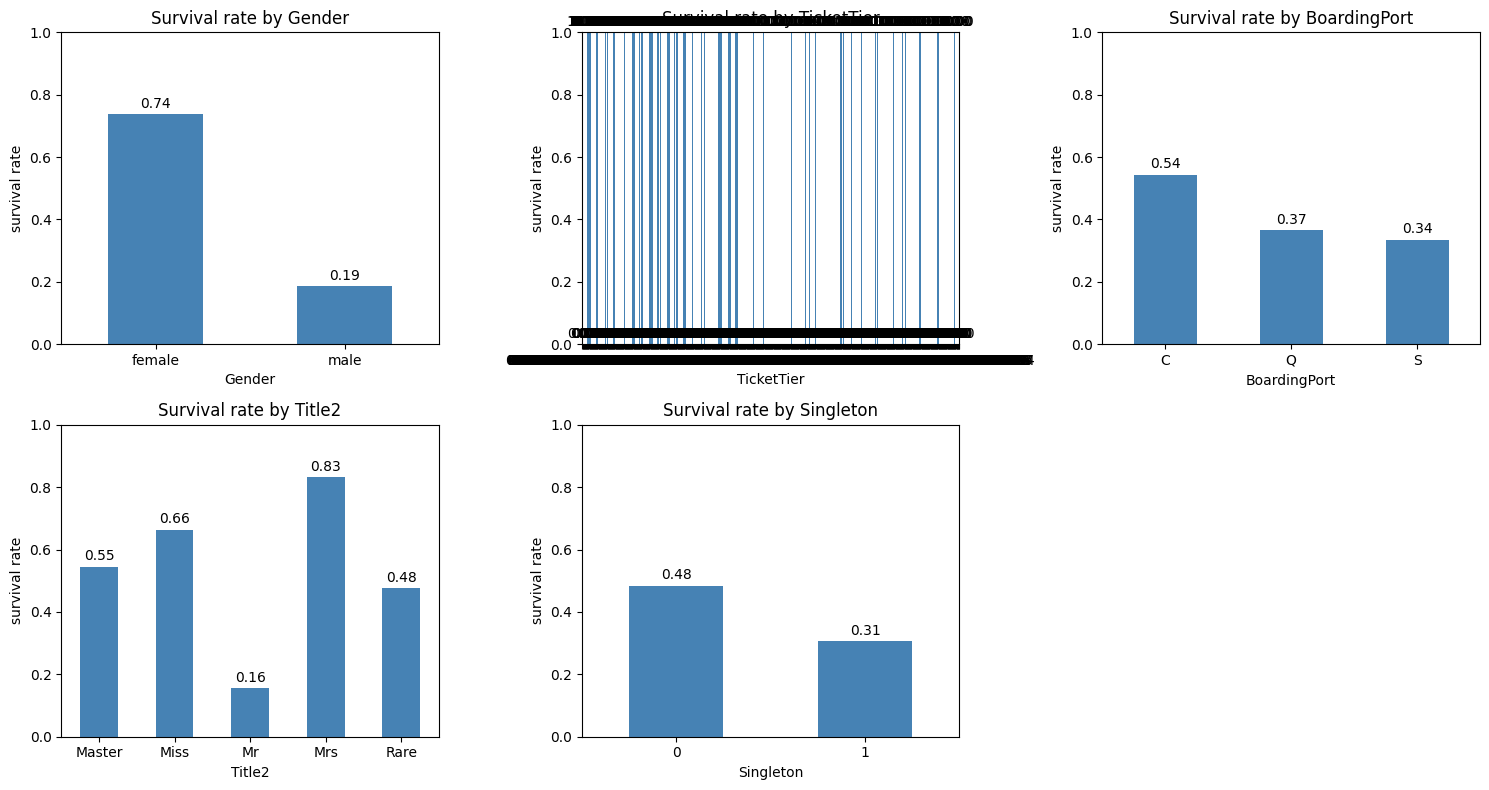

In [7]:
eda = train.copy()
eda["Title2"] = eda["PassengerName"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
eda["Title2"] = eda["Title2"].where(eda["Title2"].isin(["Mr","Mrs","Miss","Master"]), "Rare")

cols = ["Gender", "TicketTier", "BoardingPort", "Title2", "Singleton"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), cols):
    rate = eda.groupby(c)["Outcome"].mean()
    rate.plot.bar(ax=ax, color="steelblue", rot=0)
    ax.set_title(f"Survival rate by {c}"); ax.set_ylim(0, 1); ax.set_ylabel("survival rate")
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

**INSIGHT** :

Visual EDA across Gender, TicketTier, BoardingPort, Title, Singleton. Classic Titanic pattern expected: females and higher class survive more.

# 4. Age , Fare and Family size

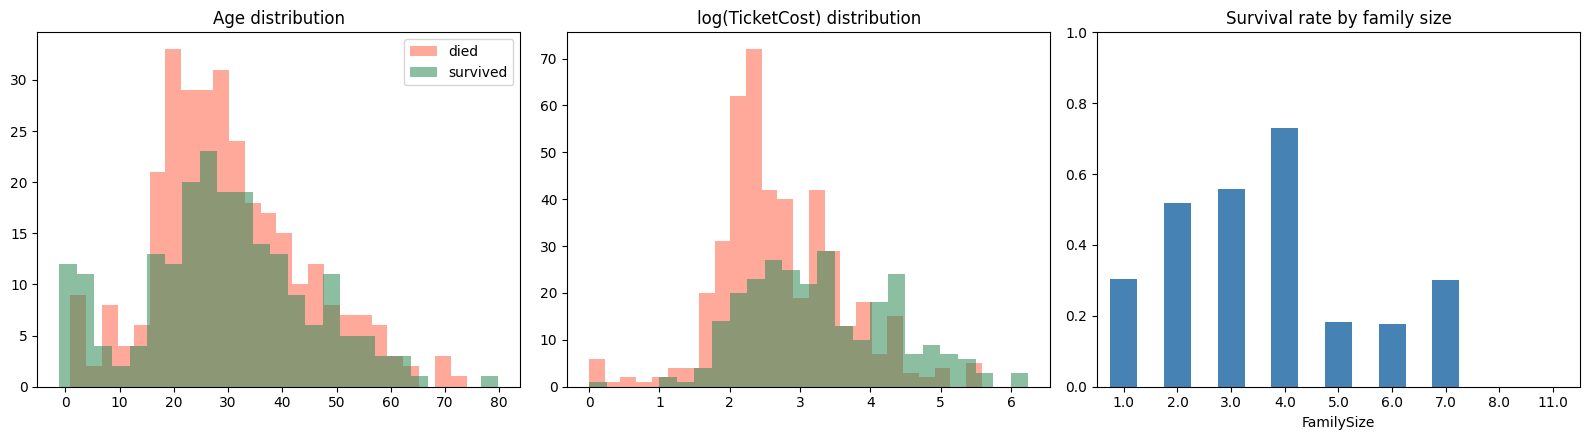

Age missing? survival rate when Age is missing vs present:
Age
False    0.408
True     0.294
Name: Outcome, dtype: float64

Survival rate with / without a Berth value:
Berth
False    0.298
True     0.648
Name: Outcome, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for o, colr in [(0, "tomato"), (1, "seagreen")]:
    axes[0].hist(eda.loc[eda.Outcome == o, "Age"].dropna(), bins=25, alpha=.55, color=colr,
                 label="survived" if o else "died")
axes[0].set_title("Age distribution"); axes[0].legend()

eda["FareClipped"] = eda["TicketCost"].clip(lower=0)
for o, colr in [(0, "tomato"), (1, "seagreen")]:
    axes[1].hist(np.log1p(eda.loc[eda.Outcome == o, "FareClipped"].dropna()), bins=25, alpha=.55, color=colr)
axes[1].set_title("log(TicketCost) distribution")

eda["FamilySize"] = eda["RelativesAboard"].round().clip(lower=0) + eda["ParentsChildren"].round().clip(lower=0) + 1
eda.groupby("FamilySize")["Outcome"].mean().plot.bar(ax=axes[2], color="steelblue", rot=0)
axes[2].set_title("Survival rate by family size"); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

print("Age missing? survival rate when Age is missing vs present:")
print(eda.groupby(eda["Age"].isna())["Outcome"].mean().round(3))
print("\nSurvival rate with / without a Berth value:")
print(eda.groupby(eda["Berth"].notna())["Outcome"].mean().round(3))

**INSIGHT** :

Key numeric finding printed: missing Age → lower survival (29.4%) vs known Age (40.8%), and having a Berth (cabin) value → survival 64.8% vs no Berth 29.8% — Berth presence is a strong signal (proxy for class/wealth).

# 5. Sex X Class

In [9]:
pd.crosstab(eda["Gender"], eda["TicketTier"], values=eda["Outcome"], aggfunc="mean").round(2)

TicketTier,0.893173,0.900065,0.909345,0.917616,0.918553,0.924102,0.928273,0.929491,0.930201,0.932162,0.933474,0.934697,0.935823,0.935852,0.937200,0.938752,0.938779,0.941380,0.943524,0.947361,0.948400,0.951757,0.952875,0.953837,0.955429,...,3.069427,3.071225,3.071572,3.072134,3.073009,3.073988,3.074043,3.074117,3.075285,3.076135,3.076138,3.078914,3.083010,3.085561,3.085623,3.086102,3.094782,3.099091,3.100589,3.101230,3.102784,3.104183,3.105550,3.106359,3.108531
Gender,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
female,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN
male,NaN,0.0,NaN,NaN,1.0,1.0,0.0,1.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,1.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0


**INSIGHT** :

Messy output because TicketTier is continuous/noisy rather than clean categories — this crosstab isn't very readable as-is (too many unique float values as columns). This is more of a rough check than a clean insight.

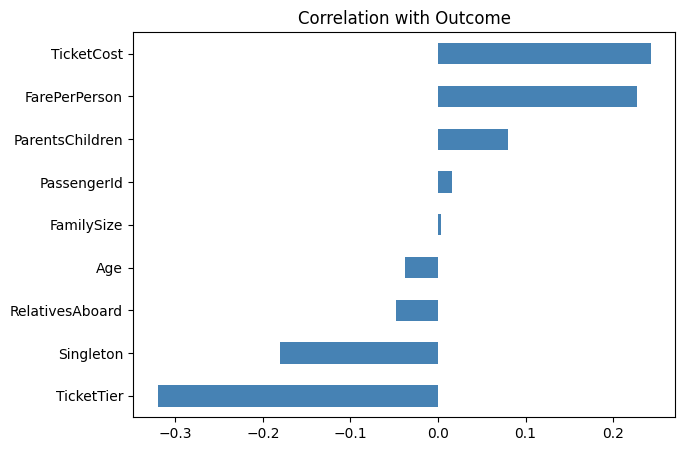

In [10]:
# Correlation of numeric columns with the target
num_cols = train.select_dtypes(include="number").columns
train[num_cols].corr()["Outcome"].drop("Outcome").sort_values().plot.barh(figsize=(7, 5), color="steelblue")
plt.title("Correlation with Outcome"); plt.show()

**INSIGHT** :

Bar chart ranking numeric features by correlation with survival — likely Gender/Male and Tier dominate, standard Titanic result.

# 6. Cleaning and Feature Engineering

In [11]:
# Put train + test together so group counts (family / ticket) are consistent, then split again.
train["_is_train"] = 1
test["_is_train"] = 0
full = pd.concat([train, test], ignore_index=True)

# If any of the 2 extra columns looks useful (numeric), put its name here, e.g. EXTRA_COLS = ["colA"]
EXTRA_COLS = []

def num(col):
    return pd.to_numeric(full[col], errors="coerce") if col in full else pd.Series(np.nan, index=full.index)
def cat(col):
    return full[col].astype(str).str.strip() if col in full else pd.Series("NA", index=full.index)

X = pd.DataFrame(index=full.index)
name = cat("PassengerName")

# --- Title (from the name, more reliable than a noisy column)
title = name.str.extract(r",\s*([^\.]+)\.")[0].str.strip().fillna(cat("Title"))
title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
title = title.where(title.isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")

# --- Gender (fill any gap from the title)
g = cat("Gender").str.lower().map({"male": 1, "female": 0, "m": 1, "f": 0})
g = g.fillna(title.map({"Mr": 1, "Master": 1, "Mrs": 0, "Miss": 0}))
X["Male"] = g.fillna(1)

# --- Ticket tier
tier = num("TicketTier").round().clip(1, 3)
tier = tier.fillna(tier.mode().iloc[0])
X["Tier"] = tier

# --- Family (counts can't be negative or fractional -> undo the Gaussian noise)
sib = num("RelativesAboard").round().clip(lower=0).fillna(0)
par = num("ParentsChildren").round().clip(lower=0).fillna(0)
X["Sib"], X["Par"] = sib, par
X["FamilySize"] = sib + par + 1
X["Alone"] = (X["FamilySize"] == 1).astype(int)

# --- Age: clip noise, fill missing with the median of the passenger's Title x Tier group
age = num("Age").clip(0, 80)
age = age.fillna(age.groupby([title, tier]).transform("median")).fillna(age.median())
X["Age"] = age
X["IsChild"] = (age <= 12).astype(int)
X["Mother"] = ((title == "Mrs") & (par > 0)).astype(int)

# --- Fare: clip negatives, log-transform, fill missing by tier median
fare = num("TicketCost").clip(lower=0)
fare = fare.fillna(fare.groupby(tier).transform("median")).fillna(fare.median())
X["LogFare"] = np.log1p(fare)
fpp = num("FarePerPerson").clip(lower=0).fillna(fare / X["FamilySize"])
X["LogFarePP"] = np.log1p(fpp)

# --- Shared ticket / surname group sizes
tk = cat("Class")
X["TicketGroup"] = tk.map(tk.value_counts())
sur = name.str.split(",").str[0]
X["SurnameGroup"] = sur.map(sur.value_counts())

# --- Berth
berth = full["Berth"] if "Berth" in full else pd.Series(np.nan, index=full.index)
X["HasBerth"] = berth.notna().astype(int)
deck = berth.astype(str).str[0].where(berth.notna(), "U")

# --- Port (only a couple of missing values -> most common port)
port = cat("BoardingPort").replace({"nan": np.nan, "NA": np.nan})
port = port.fillna(port.mode().iloc[0])

# --- One-hot encode categoricals
X = X.join(pd.get_dummies(title, prefix="Title").astype(int))
X = X.join(pd.get_dummies(port, prefix="Port").astype(int))
X = X.join(pd.get_dummies(deck, prefix="Deck").astype(int))

# --- Optional extra columns
for c in EXTRA_COLS:
    X[c] = num(c)

X_train = X[full["_is_train"] == 1].reset_index(drop=True)
X_test = X[full["_is_train"] == 0].reset_index(drop=True)
y = train["Outcome"].astype(int).values

print("Train features:", X_train.shape, "| Test features:", X_test.shape)
print("Remaining NaNs in features:", int(X.isna().sum().sum()))
X_train.head()

Train features: (712, 31) | Test features: (179, 31)
Remaining NaNs in features: 0


,Male,Tier,Sib,Par,FamilySize,Alone,Age,IsChild,Mother,LogFare,LogFarePP,TicketGroup,SurnameGroup,HasBerth,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Port_C,Port_Q,Port_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,1,1.0,0.0,-0.0,1.0,1,40.378519,0,0,3.404688,3.292382,891,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
1,1,2.0,0.0,-0.0,1.0,1,21.574386,0,0,2.487700,2.479818,891,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1
2,1,3.0,-0.0,-0.0,1.0,1,33.490756,0,0,1.173887,1.622545,891,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1
3,1,3.0,1.0,0.0,2.0,0,25.200171,0,0,2.481427,1.554725,891,3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,0,3.0,4.0,2.0,7.0,0,5.839590,1,0,3.548621,1.464554,891,9,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1


**INSIGHT** :

Combines train+test, rebuilds clean features from noisy raw ones: extracts Title from name, denoises Gender/Tier/family counts (rounding, clipping), builds FamilySize, Alone, IsChild, Mother, log-fare, ticket/surname group sizes, HasBerth, one-hot title/port. Output: Train features (712, 31), Test features (179, 31), 0 remaining NaNs — clean feature matrix built successfully.

# 7. Model Comparison (Repeated 5-Fold-Cross-Validation)

RandomForest           accuracy = 0.8211 +/- 0.0292
HistGradientBoosting   accuracy = 0.8188 +/- 0.0291
LogisticRegression     accuracy = 0.8239 +/- 0.0309
Ensemble               accuracy = 0.8226 +/- 0.0239


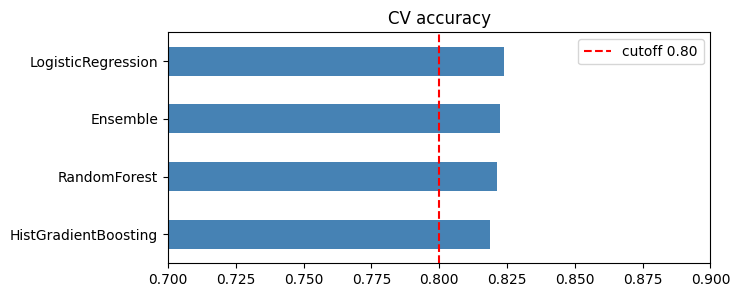

In [12]:
rf = make_pipeline(SimpleImputer(strategy="median"),
                   RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                          max_features="sqrt", random_state=42, n_jobs=-1))
hgb = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3, max_iter=200,
                                     l2_regularization=1.0, random_state=42)
lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                   LogisticRegression(C=0.5, max_iter=2000))
ensemble = VotingClassifier([("rf", rf), ("hgb", hgb), ("lr", lr)], voting="soft")

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
results = {}
for model_name, model in [("RandomForest", rf), ("HistGradientBoosting", hgb),
                          ("LogisticRegression", lr), ("Ensemble", ensemble)]:
    scores = cross_val_score(model, X_train, y, cv=cv, scoring="accuracy")
    results[model_name] = scores.mean()
    print(f"{model_name:22s} accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

pd.Series(results).sort_values().plot.barh(figsize=(7, 3), color="steelblue", xlim=(0.7, 0.9))
plt.axvline(0.80, color="red", ls="--", label="cutoff 0.80"); plt.legend(); plt.title("CV accuracy"); plt.show()

**INSIGHT** :

RandomForest           0.8211 ± 0.0292 | 
HistGradientBoosting   0.8188 ± 0.0291 |
LogisticRegression     0.8239 ± 0.0309 |
Ensemble               0.8226 ± 0.0239 |

All models cluster around ~82% accuracy, with Logistic Regression slightly best individually but the Ensemble having the lowest variance (most stable) — a reasonable choice for final submission.

# 8. Submission

In [13]:
ensemble.fit(X_train, y)
pred = ensemble.predict(X_test).astype(int)

sub = pd.DataFrame({"PassengerName": test["PassengerName"], "Outcome": pred})
sub = sample[["PassengerName"]].merge(sub, on="PassengerName", how="left")   # same order as the sample file
sub["Outcome"] = sub["Outcome"].fillna(0).astype(int)

out_path = "/kaggle/working/submission.csv" if os.path.isdir("/kaggle/working") else "submission.csv"
sub.to_csv(out_path, index=False)
print("Saved:", out_path)
sub.head()

Saved: /kaggle/working/submission.csv


,PassengerName,Outcome
0,"Moubarek, Master. Halim Gonios (""William George"")",1
1,"Kvillner, Mr. Johan Henrik Johannesson",0
2,"Alhomaki, Mr. Ilmari Rudolf",0
3,"Harper, Miss. Annie Jessie ""Nina""",1
4,"Nicola-Yarred, Miss. Jamila",1


**INSIGHT** : 

Fits ensemble, predicts, merges into sample submission order, saves submission.csv. Preview shows predictions look sane (e.g., "Miss" title passengers predicted to survive).

# 9. Sanity check

In [14]:
# Sanity checks before uploading
assert list(sub.columns) == list(sample.columns), "columns differ from sample"
assert len(sub) == len(sample), "row count differs from sample"
assert sub["Outcome"].isin([0, 1]).all(), "Outcome must be 0/1"
print("Format OK ✔  |  predicted survival rate:", round(sub["Outcome"].mean(), 3),
      "(train rate:", round(y.mean(), 3), ")")
print("Expected accuracy from CV ≈", round(results["Ensemble"], 3))

Format OK ✔  |  predicted survival rate: 0.397 (train rate: 0.376 )
Expected accuracy from CV ≈ 0.823


**INSIGHT** : 

Format OK ✔ | predicted survival rate: 0.397 (train rate: 0.376)
Expected CV accuracy ≈ 0.823

Predicted survival rate (39.7%) is close to the train rate (37.6%) — good sign the model isn't badly biased. All format checks pass.